Numerical Results

In this section, we calculate the current density due to SEI for all models with the following parameters:

In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling Bham group
# no_cycles = 1
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)

no_cycles = 5
exp = pybamm.Experiment(
    [(
      "Charge at C/20 until 4.2 V",
       "Rest for 5 hour",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hour",
      )]* no_cycles )
# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed


sei_options = [ "ec reaction limited", "ec reaction limited", "ec reaction limited",  "electron-migration limited",  "interstitial-diffusion limited", "tunnelling limited" , "Kolzenberg2020" ]
labels_sei_options = ["RL", "Mixed", "SD", "EM", "ID", "TL", "VK"]  
k_sei =[1e-19, 1e-10, 1e-15, 1, 1, 1, 1]
D_sol = [1e-20,1e-22 ,2e-22,1, 1, 1, 1] 
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues("Chen2020")
  param['Initial inner SEI thickness [m]']=5e-13
  param['Initial outer SEI thickness [m]']=5e-13
  param['SEI kinetic rate constant [m.s-1]'] =k_sei[i]
  param['Outer SEI solvent diffusivity [m2.s-1]' ]=D_sol[i]
  param['Bulk solvent concentration [mol.m-3]']= 4541.0
  # param['Inner SEI open-circuit potential [V]']=0.4
  # param['Outer SEI open-circuit potential [V]']=0.4
  param['SEI open-circuit potential [V]'] = 0.8
  param['Inner SEI electron conductivity [S.m-1]']=8.95e-15 
  param['SEI lithium ion conductivity [S.m-1]']=1.0e-7 
  param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-20
  param['Lithium interstitial reference concentration [mol.m-3]']=1000
  # param['Upper voltage cut-off [V]']=1.2
  # param['Lower voltage cut-off [V]']=0.1
  # param['Open-circuit voltage at 0% SOC [V]'] =0.1
  # param['Open-circuit voltage at 100% SOC [V]'] =1.2
  # param['Nominal cell capacity [A.h]']= 1.2
  # This has been used in Kolzenberg model 
  param['SEI reaction exchange current density [A.m-2]'] =1.5e-04
  params.append(param)

# param


/home/kawamanmi/Projects/PyBaMM


In [2]:
models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
                                  "SEI": sei_option}) for sei_option in sei_options]


pybamm.settings.max_y_value = 100000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]

In [3]:
# models[0].variable_names()
# import matplotlib.pyplot as plt
# plt.plot(sols[0].cycles[0].t, sols[0].cycles[0]
#          ['X-averaged negative total SEI thickness [m]'].entries, label="reaction limited")
# plt.plot(sols[1].cycles[0].t, sols[1].cycles[0]
#          ['X-averaged negative total SEI thickness [m]'].entries, label="reaction limited")

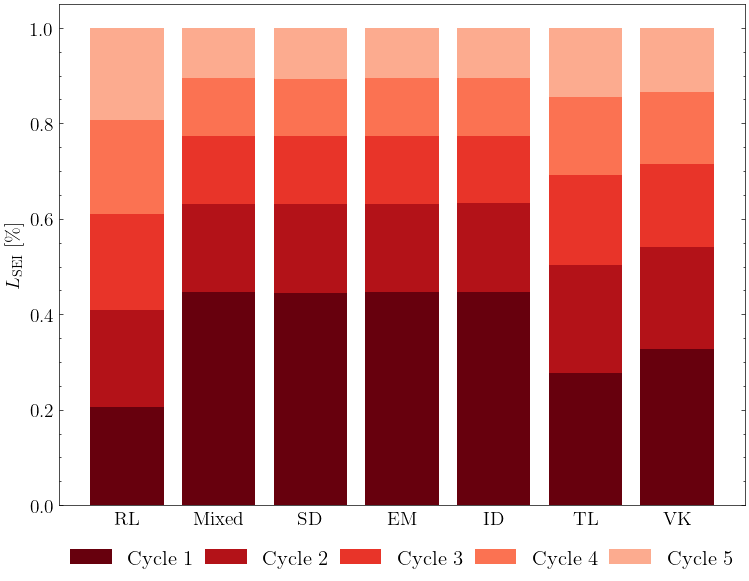

In [22]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"


# Inset subplot
# axins = inset_axes(axs[0], width="30%", height="30%",loc='upper left', bbox_to_anchor=(0.05, 0.65, 1, 1))
# axins.plot([1, 2, 3], [2, 3, 1])
# First plot

LL_values_by_sol = [[] for _ in range(len(sols))]

for index, sol in enumerate(sols):
    L_max_model = sols[index]['X-averaged negative total SEI thickness [m]'].entries[-1]
    for cycle in range(no_cycles):
        L_min_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[0]
        LL_max_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[-1]
        LL = (LL_max_cycle - L_min_cycle) / L_max_model
        LL_values_by_sol[index].append(LL)

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(sols))
bottom = np.zeros(len(sols))
colors = plt.cm.viridis(np.linspace(0, 1, no_cycles))
# change this to plt.cm.Reds for red gradient
colors = plt.cm.Reds(np.linspace(1, 0.3, no_cycles))


for cycle in range(no_cycles):
    LL_values_cycle = [LL_values_by_sol[sol_index][cycle]
                       for sol_index in range(len(sols))]
    ax.bar(x, LL_values_cycle, bottom=bottom,
           label=f'Cycle {cycle+1}', color=colors[cycle])
    bottom += LL_values_cycle

ax.set_ylabel('$L_\mathrm{SEI}$ [\%]', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticks(x)
ax.set_xticklabels([label for label in labels_sei_options], fontsize=14)
ax.tick_params(axis='x', which='both', bottom=False,
               top=False)  # remove x-axis ticks
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5, fontsize=15, columnspacing=0.5)

plt.tight_layout()
plt.savefig("figure4.pdf", format='pdf', dpi=300)
plt.show()

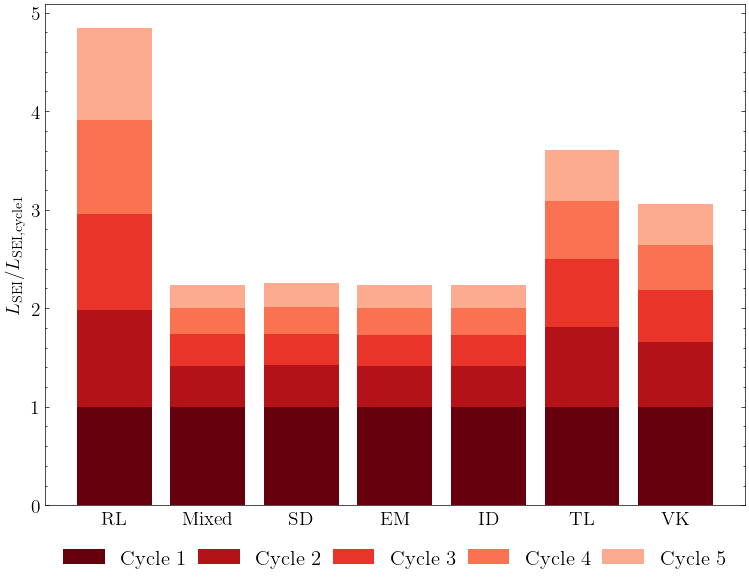

In [21]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"


# Inset subplot
# axins = inset_axes(axs[0], width="30%", height="30%",loc='upper left', bbox_to_anchor=(0.05, 0.65, 1, 1))
# axins.plot([1, 2, 3], [2, 3, 1])
# First plot

LL_values_by_sol = [[] for _ in range(len(sols))]

for index, sol in enumerate(sols):
    L_max_model = sols[index]['X-averaged negative total SEI thickness [m]'].entries[-1]
    for cycle in range(no_cycles):
        L_min_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[0]
        LL_max_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[-1]
        if cycle == 0:
            L_max_model_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[-1]
        LL = (LL_max_cycle - L_min_cycle) / L_max_model_cycle
        LL_values_by_sol[index].append(LL)

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(sols))
bottom = np.zeros(len(sols))
colors = plt.cm.viridis(np.linspace(0, 1, no_cycles))
# change this to plt.cm.Reds for red gradient
colors = plt.cm.Reds(np.linspace(1, 0.3, no_cycles))


for cycle in range(no_cycles):
    LL_values_cycle = [LL_values_by_sol[sol_index][cycle]
                       for sol_index in range(len(sols))]
    ax.bar(x, LL_values_cycle, bottom=bottom,
           label=f'Cycle {cycle+1}', color=colors[cycle])
    bottom += LL_values_cycle

ax.set_ylabel('$L_\mathrm{SEI} / L_\mathrm{SEI, cycle1}$', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticks(x)
ax.set_xticklabels([label for label in labels_sei_options], fontsize=14)
ax.tick_params(axis='x', which='both', bottom=False,
               top=False)  # remove x-axis ticks
# ax.legend(loc='upper center', bbox_to_anchor=(
#     0.5, -0.05), fancybox=True, shadow=True, ncol=5, fontsize=13.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5, fontsize=15, columnspacing=0.5)

plt.tight_layout()
plt.savefig("figure5.pdf", format='pdf', dpi=300)
plt.show()

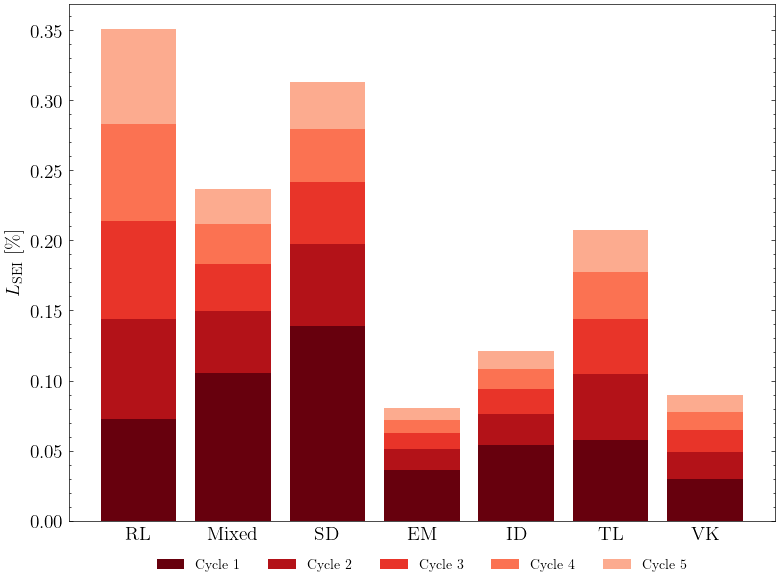

In [5]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"


# Inset subplot
# axins = inset_axes(axs[0], width="30%", height="30%",loc='upper left', bbox_to_anchor=(0.05, 0.65, 1, 1))
# axins.plot([1, 2, 3], [2, 3, 1])
# First plot

LL_values_by_sol = [[] for _ in range(len(sols))]

for index, sol in enumerate(sols):
    L_max_model = sols[index]['X-averaged negative total SEI thickness [m]'].entries[-1]
    for cycle in range(no_cycles):
        # L_min_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[0]
        # LL_max_cycle = sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries[-1]
        # LL = (LL_max_cycle - L_min_cycle) / L_max_model
        capacity_fade = (sol.cycles[cycle]['Total capacity lost to side reactions [A.h]'].entries[-1]
                         - sol.cycles[cycle]['Total capacity lost to side reactions [A.h]'].entries[0])/5 * 100
        LL_values_by_sol[index].append(capacity_fade)

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(sols))
bottom = np.zeros(len(sols))
colors = plt.cm.viridis(np.linspace(0, 1, no_cycles))
# change this to plt.cm.Reds for red gradient
colors = plt.cm.Reds(np.linspace(1, 0.3, no_cycles))


for cycle in range(no_cycles):
    LL_values_cycle = [LL_values_by_sol[sol_index][cycle]
                       for sol_index in range(len(sols))]
    ax.bar(x, LL_values_cycle, bottom=bottom,
           label=f'Cycle {cycle+1}', color=colors[cycle])
    bottom += LL_values_cycle

ax.set_ylabel('$L_\mathrm{SEI}$ [\%]', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticks(x)
ax.set_xticklabels([label for label in labels_sei_options], fontsize=14)
ax.tick_params(axis='x', which='both', bottom=False,
               top=False)  # remove x-axis ticks
ax.legend(loc='upper center', bbox_to_anchor=(
    0.5, -0.05), fancybox=True, shadow=True, ncol=5)

plt.tight_layout()
plt.savefig("figure5.pdf", format='pdf', dpi=300)
plt.show()